# Euro500 Equity Portfolio

This notebook constructs a quarterly rebalanced equity portfolio consisting of the 500 largest non-financial firms headquartered in euro-area countries. The sample starts in 1999Q1 and is used as the basis for subsequent return and event-study analyses.

## 0. Setup

In [522]:
# --- Imports & configuration ---
from pathlib import Path
import pandas as pd
import numpy as np
import lseg.data as ld
import time
import warnings

# --- Output paths (anpassen) ---
BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
(DATA_DIR := BASE_DIR / "intermediate").mkdir(parents=True, exist_ok=True)

def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

warnings.filterwarnings(
    "ignore",
    message=r".*Downcasting behavior in `replace` is deprecated.*",
    category=FutureWarning,
    module=r"lseg\.data\._tools\._dataframe"
)

## 1. Definition of the Investment Universe

### 1.1 Euro-Area Headquartered Firms

The initial universe consists of all publicly listed, active, primary equity instruments whose headquarters are located in a euro-area country.

In [523]:
import pandas as pd

EURO_ADOPTION = {
    # Founding members (book money from 1999-01-01)
    "AT": "1999-01-01",
    "BE": "1999-01-01",
    "FI": "1999-01-01",
    "FR": "1999-01-01",
    "DE": "1999-01-01",
    "IE": "1999-01-01",
    "IT": "1999-01-01",
    "LU": "1999-01-01",
    "NL": "1999-01-01",
    "PT": "1999-01-01",
    "ES": "1999-01-01",

    # Later entrants
    "GR": "2001-01-01",
    "SI": "2007-01-01",
    "CY": "2008-01-01",
    "MT": "2008-01-01",
    "SK": "2009-01-01",
    "EE": "2011-01-01",
    "LV": "2014-01-01",
    "LT": "2015-01-01",
    "HR": "2023-01-01",
}

EURO_ADOPTION_DT = {k: pd.Timestamp(v) for k, v in EURO_ADOPTION.items()}

def euro_hq_codes_for_quarter(formation_date: pd.Timestamp) -> list[str]:
    """
    Countries eligible for the euro area in the return period
    following the portfolio formation date.
    """
    eligibility_date = formation_date + pd.Timedelta(days=1)
    return sorted(
        c for c, d in EURO_ADOPTION_DT.items()
        if d <= eligibility_date
    )

# Broad common-equity filter (historical labels differ across years/venues)
COMMON_EQUITY_TYPE_PATTERNS = [
    "ordinary",
    "common",
    "registered",
    "voting",
    "aandeel",
    "aktion",
]

EXCLUDED_TYPE_PATTERNS = [
    "etf",
    "fund",
    "warrant",
    "certificate",
    "pref",
    "preferred",
    "adr",
    "gdr",
    "unit",
    "right",
]

def is_common_equity_type(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()
    keep = pd.Series(False, index=s.index)
    for pat in COMMON_EQUITY_TYPE_PATTERNS:
        keep = keep | s.str.contains(pat, na=False)
    for pat in EXCLUDED_TYPE_PATTERNS:
        keep = keep & ~s.str.contains(pat, na=False)
    return keep




### Screen Builder

In [524]:
def make_screen_euro_all_for_quarter(formation_date: pd.Timestamp) -> str:
    """
    SCREEN universe for euro-area headquartered ordinary shares only.
    """

    codes = euro_hq_codes_for_quarter(formation_date)
    codes = [c for c in codes if isinstance(c, str) and c.strip() != ""]

    if not codes:
        codes_str = '"ZZ"'
    else:
        codes_str = ",".join(f'"{c}"' for c in codes)

    screen = (
        "SCREEN("
        # Only active, public, primary listings
        "U(IN(Equity(active,public,primary))),"
        # HQ filter
        f"IN(TR.HQCountryCode,{codes_str}),"
        # Normalize currency
        "CURN=EUR"
        ")"
    )

    return screen




In [525]:
def pull_euro_equities_snapshot(formation_date: pd.Timestamp, max_retries: int = 3, sleep_s: float = 2.0):
    formation_date = pd.Timestamp(formation_date).normalize()
    date_iso = formation_date.strftime("%Y-%m-%d")

    # SCREEN universe (string)
    universe = [make_screen_euro_all_for_quarter(formation_date)]

    fields = [
        "TR.RIC",
        "TR.PrimaryRIC",
        "TR.ISIN",
        "TR.SEDOL",
        "TR.CommonName",
        "TR.HeadquartersCountry",
        "TR.HQCountryCode",
        "TR.TRBCEconomicSector",
        "TR.CompanyMarketCap",
        "TR.MarketCap",
        "TR.FreeFloat",
        "TR.FreeFloatPct",
        "TR.Volume",
        "TR.PriceClose",
        "TR.InstrumentType",
    ]

    parameters = {
        "CURN": "EUR",
        "RH": "In",
        "CH": "Fd",
        "SDate": date_iso,
        "EDate": date_iso,
    }

    last_err = None

    for attempt in range(1, max_retries + 1):
        try:
            ld.open_session()
            try:
                df = ld.get_data(universe=universe, fields=fields, parameters=parameters)
            finally:
                ld.close_session()

            if df is None or df.empty:
                return pd.DataFrame()

            df = df.copy()

            # ---- IMPORTANT: strip empty identifiers (prevents downstream & some backend issues) ----
            for c in ["TR.RIC", "TR.PrimaryRIC", "TR.ISIN", "TR.SEDOL"]:
                if c in df.columns:
                    df[c] = df[c].astype(str).str.strip()
                    df.loc[df[c] == "", c] = pd.NA

            # IDs
            if "TR.RIC" in df.columns:
                df["RIC_snapshot"] = df["TR.RIC"]
            else:
                df["RIC_snapshot"] = pd.NA

            if "TR.PrimaryRIC" in df.columns:
                df["RIC_current"] = df["TR.PrimaryRIC"].fillna(df.get("TR.RIC"))
            else:
                df["RIC_current"] = df.get("TR.RIC")

            # MasterID: ISIN -> SEDOL -> RIC_current
            df["MasterID"] = df.get("TR.ISIN").fillna(df.get("TR.SEDOL")).fillna(df.get("RIC_current"))

            # Rename columns
            df = df.rename(columns={
                "TR.CommonName": "CompanyName",
                "TR.HeadquartersCountry": "HQCountry",
                "TR.HQCountryCode": "HQCountryCode",
                "TR.TRBCEconomicSector": "Sector",
                "TR.CompanyMarketCap": "CompanyMarketCap_EUR",
                "TR.MarketCap": "MarketCap_EUR",
                "TR.ISIN": "ISIN",
                "TR.SEDOL": "SEDOL",
                "TR.FreeFloat": "FreeFloat",
                "TR.FreeFloatPct": "FreeFloatPct",
                "TR.Volume": "Volume",
                "TR.PriceClose": "PriceClose",
                "TR.InstrumentType": "InstrumentType",
            })

            # Numeric coercion
            for c in ["CompanyMarketCap_EUR", "MarketCap_EUR", "FreeFloat", "FreeFloatPct", "Volume", "PriceClose"]:
                if c in df.columns:
                    df[c] = pd.to_numeric(df[c], errors="coerce")

            return df

        except Exception as e:
            last_err = e
            time.sleep(sleep_s * attempt)

    raise last_err

In [526]:
for d in [
    pd.Timestamp("1998-12-31"),
    pd.Timestamp("2001-03-31"),
    pd.Timestamp("2008-03-31"),
    pd.Timestamp("2015-03-31"),
    pd.Timestamp("2025-03-31"),
]:
    print(d.date(), euro_hq_codes_for_quarter(d))

1998-12-31 ['AT', 'BE', 'DE', 'ES', 'FI', 'FR', 'IE', 'IT', 'LU', 'NL', 'PT']
2001-03-31 ['AT', 'BE', 'DE', 'ES', 'FI', 'FR', 'GR', 'IE', 'IT', 'LU', 'NL', 'PT']
2008-03-31 ['AT', 'BE', 'CY', 'DE', 'ES', 'FI', 'FR', 'GR', 'IE', 'IT', 'LU', 'MT', 'NL', 'PT', 'SI']
2015-03-31 ['AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK']
2025-03-31 ['AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'HR', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK']


### 1.2 Period

Every Quater from 1999 to 2025

In [527]:
# Quarter schedule: formation_date (last business day of previous quarter)
# and effective_date (first business day of current quarter)
START_QUARTER = "1999Q1"
TODAY = pd.Timestamp.today().normalize()
LAST_COMPLETED_Q = TODAY.to_period("Q") - 1

quarters = pd.period_range(START_QUARTER, LAST_COMPLETED_Q, freq="Q")
rebalance_calendar = pd.DataFrame({"quarter": quarters.astype(str)})
rebalance_calendar["effective_date"] = quarters.to_timestamp(how="start")
rebalance_calendar["effective_date"] = pd.to_datetime(rebalance_calendar["effective_date"]) + pd.offsets.BDay(0)
rebalance_calendar["formation_date"] = rebalance_calendar["effective_date"] - pd.offsets.BDay(1)

print("Today:", TODAY.date())
print("Last completed quarter:", str(LAST_COMPLETED_Q))
print("First rows:")
display(rebalance_calendar.head())
print("Last rows:")
display(rebalance_calendar.tail())

Today: 2026-02-13
Last completed quarter: 2025Q4
First rows:


,quarter,effective_date,formation_date
0,1999Q1,1999-01-01,1998-12-31
1,1999Q2,1999-04-01,1999-03-31
2,1999Q3,1999-07-01,1999-06-30
3,1999Q4,1999-10-01,1999-09-30
4,2000Q1,2000-01-03,1999-12-31


Last rows:


,quarter,effective_date,formation_date
103,2024Q4,2024-10-01,2024-09-30
104,2025Q1,2025-01-01,2024-12-31
105,2025Q2,2025-04-01,2025-03-31
106,2025Q3,2025-07-01,2025-06-30
107,2025Q4,2025-10-01,2025-09-30


## 2. Workspace Screener

In [528]:
# ------------------------------------------------------------
# Cache: quarterly snapshots
# ------------------------------------------------------------
CACHE_DIR = DATA_DIR / "euro_snap_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _cache_path(formation_date: pd.Timestamp) -> Path:
    d = pd.Timestamp(formation_date).strftime("%Y-%m-%d")
    return CACHE_DIR / f"euro_snapshot_{d}.parquet"


# ------------------------------------------------------------
# Helpers: clean universes + robust retry wrapper
# ------------------------------------------------------------
def _clean_universe_list(x):
    """Drop NA/empty/whitespace-only and ensure unique strings."""
    s = pd.Series(x).dropna().astype(str)
    s = s[s.str.strip() != ""]
    return s.unique().tolist()

def _safe_get_data(universe, fields, parameters, max_retries=3, base_sleep=2.0):
    """Robust ld.get_data with cleaned universe + retry."""
    universe = _clean_universe_list(universe)
    if not universe:
        return pd.DataFrame()

    last = None
    for r in range(1, max_retries + 1):
        try:
            df = ld.get_data(universe=universe, fields=fields, parameters=parameters)
            if df is None:
                return pd.DataFrame()
            return df
        except Exception as e:
            last = e
            time.sleep(base_sleep * r)
    raise last


def _best_col(df: pd.DataFrame, candidates: list[str]):
    cols = list(df.columns)
    lower = {str(c).lower(): c for c in cols}
    for c in candidates:
        if c in df.columns:
            return c
        cl = str(c).lower()
        if cl in lower:
            return lower[cl]
    return None


def _to_num(s):
    return pd.to_numeric(s, errors="coerce")


def _mcap_coverage(df: pd.DataFrame) -> float:
    if df is None or len(df) == 0 or "mcap_eur" not in df.columns:
        return 0.0
    return float(df["mcap_eur"].notna().mean())


def _augment_missing_with_backfill_window(
    out: pd.DataFrame,
    formation_date: pd.Timestamp,
    max_retries: int = 3,
    sleep_s: float = 2.0,
    offsets_days: tuple[int, ...] = (1, 2, 3, 5, 7, 10, 15, 20),
) -> pd.DataFrame:
    """
    Improve early-history coverage (e.g. 1998-12-31) by filling missing fields
    from prior business days for the same RIC.
    """
    if out is None or out.empty:
        return out

    out = out.copy()
    fill_cols = ["mcap_eur", "PriceClose", "FreeFloatPct", "FreeFloat", "Volume"]
    for c in fill_cols:
        if c not in out.columns:
            out[c] = np.nan

    backfill_fields = [
        "TR.RIC",
        "TR.CompanyMarketCap",
        "TR.MarketCap",
        "TR.PriceClose",
        "TR.FreeFloatPct",
        "TR.FreeFloat",
        "TR.Volume",
        "TR.SharesOutstanding",
        "TR.CompanySharesOutstanding",
    ]

    for off in offsets_days:
        missing_mask = out[fill_cols].isna().any(axis=1)
        miss_rics = _clean_universe_list(out.loc[missing_mask, "RIC"].tolist())
        if not miss_rics:
            break

        d = (pd.Timestamp(formation_date) - pd.Timedelta(days=off)).strftime("%Y-%m-%d")
        params = {"CURN": "EUR", "RH": "In", "CH": "Fd", "SDate": d, "EDate": d}

        try:
            ld.open_session()
            try:
                raw = _safe_get_data(
                    universe=miss_rics,
                    fields=backfill_fields,
                    parameters=params,
                    max_retries=max_retries,
                    base_sleep=sleep_s,
                )
            finally:
                ld.close_session()
        except Exception:
            continue

        if raw is None or len(raw) == 0:
            continue

        col_ric = _best_col(raw, ["RIC", "TR.RIC", "Instrument"])
        if col_ric is None:
            continue

        col_company_mcap = _best_col(raw, ["Company Market Cap", "TR.CompanyMarketCap", "TR.COMPANYMARKETCAP"])
        col_instr_mcap = _best_col(raw, ["Market Cap", "TR.MarketCap", "TR.MARKETCAP"])
        col_px = _best_col(raw, ["TR.PriceClose", "Price Close", "Close Price", "TR.PRICECLOSE", "TR.CLOSEPRICE"])
        col_ffpct = _best_col(raw, ["TR.FreeFloatPct", "Free Float Percent", "TR.FREEFLOATPCT"])
        col_ff = _best_col(raw, ["TR.FreeFloat", "Free Float", "TR.FREEFLOAT"])
        col_vol = _best_col(raw, ["TR.Volume", "Volume", "TR.VOLUME"])
        col_sh1 = _best_col(raw, ["TR.SharesOutstanding", "Shares Outstanding", "TR.SHARESOUTSTANDING"])
        col_sh2 = _best_col(raw, ["TR.CompanySharesOutstanding", "TR.COMPANYSHARESOUTSTANDING"])

        upd = pd.DataFrame({"RIC": raw[col_ric].astype(str).str.strip()})
        upd = upd[upd["RIC"] != ""].copy()

        mcap_company = _to_num(raw[col_company_mcap]) if col_company_mcap else pd.Series(np.nan, index=raw.index, dtype="float64")
        mcap_instr = _to_num(raw[col_instr_mcap]) if col_instr_mcap else pd.Series(np.nan, index=raw.index, dtype="float64")
        mcap_from_fields = mcap_company.combine_first(mcap_instr)

        px = _to_num(raw[col_px]) if col_px else pd.Series(np.nan, index=raw.index, dtype="float64")
        sh1 = _to_num(raw[col_sh1]) if col_sh1 else pd.Series(np.nan, index=raw.index, dtype="float64")
        sh2 = _to_num(raw[col_sh2]) if col_sh2 else pd.Series(np.nan, index=raw.index, dtype="float64")
        shares = sh1.combine_first(sh2)
        mcap_synth = px * shares

        upd["mcap_eur"] = mcap_from_fields.combine_first(mcap_synth)
        upd["PriceClose"] = px
        upd["FreeFloatPct"] = _to_num(raw[col_ffpct]) if col_ffpct else np.nan
        upd["FreeFloat"] = _to_num(raw[col_ff]) if col_ff else np.nan
        upd["Volume"] = _to_num(raw[col_vol]) if col_vol else np.nan

        upd = upd.drop_duplicates(subset=["RIC"], keep="first")
        out = out.merge(upd, on="RIC", how="left", suffixes=("", "_bf"))

        for c in fill_cols:
            bf = f"{c}_bf"
            if bf in out.columns:
                out[c] = _to_num(out[c]).fillna(_to_num(out[bf]))
                out = out.drop(columns=[bf])

    return out


# ------------------------------------------------------------
# Main: pull quarterly Euro equities snapshot (safe + cached)
# ------------------------------------------------------------
def pull_euro_equities_snapshot_safe(
    formation_date,
    max_retries: int = 3,
    sleep_s: float = 2.0,
    min_cached_mcap_coverage: float = 0.60,
    min_target_mcap_coverage: float = 0.85,
    enable_backfill: bool = False,
) -> pd.DataFrame:
    """
    Safe wrapper: cache + retry + robust market-cap fallback.
    """
    formation_date = pd.Timestamp(formation_date).normalize()
    date_iso = formation_date.strftime("%Y-%m-%d")

    p = _cache_path(formation_date)
    if p.exists():
        # Always trust existing cache files; do not refresh on coverage.
        return pd.read_parquet(p)

    universe = [make_screen_euro_all_for_quarter(formation_date)]

    base = [
        "TR.RIC", "TR.PrimaryRIC", "TR.ISIN", "TR.SEDOL",
        "TR.CommonName", "TR.HeadquartersCountry", "TR.HQCountryCode",
        "TR.TRBCEconSectorCode", "TR.TRBCEconomicSector",
        "TR.FreeFloat", "TR.FreeFloatPct", "TR.Volume", "TR.PriceClose", "TR.InstrumentType",
        "TR.SharesOutstanding", "TR.CompanySharesOutstanding",
    ]

    field_sets = [
        base + ["TR.CompanyMarketCap", "TR.MarketCap"],
        base + ["TR.MarketCap"],
        base + ["TR.CompanyMarketCap"],
    ]

    params = {"CURN": "EUR", "RH": "In", "CH": "Fd", "SDate": date_iso, "EDate": date_iso}

    last_err = None

    for fields in field_sets:
        for attempt in range(1, max_retries + 1):
            try:
                ld.open_session()
                try:
                    df = _safe_get_data(
                        universe=universe,
                        fields=fields,
                        parameters=params,
                        max_retries=max_retries,
                        base_sleep=sleep_s,
                    ).copy()
                finally:
                    ld.close_session()

                if df is None or len(df) == 0:
                    out = pd.DataFrame(columns=[
                        "RIC", "name", "hq_country", "hq_code",
                        "trbc_sector_code", "trbc_sector", "mcap_eur",
                        "RIC_snapshot", "RIC_current", "ISIN", "SEDOL", "MasterID",
                        "FreeFloat", "FreeFloatPct", "Volume", "PriceClose", "InstrumentType",
                    ])
                    out.to_parquet(p, index=False)
                    return out

                col_ric = _best_col(df, ["RIC", "TR.RIC", "Instrument"])
                col_name = _best_col(df, ["Company Common Name", "TR.CommonName", "TR.COMMONNAME"])
                col_hq_country = _best_col(df, ["Country of Headquarters", "TR.HeadquartersCountry", "TR.HEADQUARTERSCOUNTRY"])
                col_hq_code = _best_col(df, ["Country ISO Code of Headquarters", "TR.HQCountryCode", "TR.HQCOUNTRYCODE"])
                col_trbc_code = _best_col(df, ["TRBC Economic Sector Code", "TR.TRBCEconSectorCode", "TR.TRBCECONSECTORCODE"])
                col_trbc_name = _best_col(df, ["TRBC Economic Sector Name", "TR.TRBCEconomicSector", "TR.TRBCECONOMICSECTOR"])

                col_company_mcap = _best_col(df, ["Company Market Cap", "TR.CompanyMarketCap", "TR.COMPANYMARKETCAP"])
                col_instr_mcap = _best_col(df, ["Market Cap", "TR.MarketCap", "TR.MARKETCAP"])

                col_primary = _best_col(df, ["TR.PrimaryRIC", "TR.PRIMARYRIC", "Primary Issue RIC", "Primary RIC"])
                col_isin = _best_col(df, ["TR.ISIN", "TR.ISINCode", "ISIN", "TR.ISINCODE"])
                col_sedol = _best_col(df, ["TR.SEDOL", "SEDOL", "TR.SEDOLCode", "TR.SEDOLCODE"])

                col_ff = _best_col(df, ["TR.FreeFloat", "Free Float", "TR.FREEFLOAT"])
                col_ffpct = _best_col(df, ["TR.FreeFloatPct", "Free Float (Percent)", "Free Float Percent", "TR.FREEFLOATPCT"])
                col_vol = _best_col(df, ["TR.Volume", "Volume", "TR.VOLUME"])
                col_px = _best_col(df, ["TR.PriceClose", "Price Close", "Close Price", "TR.PRICECLOSE", "TR.CLOSEPRICE"])
                col_type = _best_col(df, ["TR.InstrumentType", "Instrument Type", "TR.INSTRUMENTTYPE"])

                col_sh1 = _best_col(df, ["TR.SharesOutstanding", "Shares Outstanding", "TR.SHARESOUTSTANDING"])
                col_sh2 = _best_col(df, ["TR.CompanySharesOutstanding", "TR.COMPANYSHARESOUTSTANDING"])

                if col_ric is None:
                    raise KeyError(f"No RIC column. Got: {list(df.columns)}")

                if col_company_mcap is None and col_instr_mcap is None:
                    raise KeyError(f"No market-cap column. Got: {list(df.columns)}")

                mcap_company = _to_num(df[col_company_mcap]) if col_company_mcap else pd.Series(np.nan, index=df.index, dtype="float64")
                mcap_instr = _to_num(df[col_instr_mcap]) if col_instr_mcap else pd.Series(np.nan, index=df.index, dtype="float64")

                px = _to_num(df[col_px]) if col_px else pd.Series(np.nan, index=df.index, dtype="float64")
                sh1 = _to_num(df[col_sh1]) if col_sh1 else pd.Series(np.nan, index=df.index, dtype="float64")
                sh2 = _to_num(df[col_sh2]) if col_sh2 else pd.Series(np.nan, index=df.index, dtype="float64")
                shares = sh1.combine_first(sh2)

                mcap_eur = mcap_company.combine_first(mcap_instr).combine_first(px * shares)

                out = pd.DataFrame({
                    "RIC": df[col_ric],
                    "name": df[col_name] if col_name else pd.NA,
                    "hq_country": df[col_hq_country] if col_hq_country else pd.NA,
                    "hq_code": df[col_hq_code] if col_hq_code else pd.NA,
                    "trbc_sector_code": df[col_trbc_code] if col_trbc_code else pd.NA,
                    "trbc_sector": df[col_trbc_name] if col_trbc_name else pd.NA,
                    "mcap_eur": mcap_eur,

                    "RIC_snapshot": df[col_ric],
                    "RIC_current": df[col_primary] if col_primary else df[col_ric],
                    "ISIN": df[col_isin] if col_isin else pd.NA,
                    "SEDOL": df[col_sedol] if col_sedol else pd.NA,

                    "FreeFloat": df[col_ff] if col_ff else pd.NA,
                    "FreeFloatPct": df[col_ffpct] if col_ffpct else pd.NA,
                    "Volume": df[col_vol] if col_vol else pd.NA,
                    "PriceClose": px,
                    "InstrumentType": df[col_type] if col_type else pd.NA,
                })

                for idc in ["RIC", "RIC_snapshot", "RIC_current", "ISIN", "SEDOL"]:
                    out[idc] = out[idc].astype(str).str.strip()
                    out.loc[out[idc] == "", idc] = pd.NA

                out["MasterID"] = out["ISIN"].fillna(out["SEDOL"]).fillna(out["RIC_current"])

                for c in ["mcap_eur", "FreeFloat", "FreeFloatPct", "Volume", "PriceClose"]:
                    out[c] = pd.to_numeric(out[c], errors="coerce")

                out = out.dropna(subset=["RIC"]).copy()

                cov_before = _mcap_coverage(out)
                if enable_backfill and cov_before < min_target_mcap_coverage:
                    out = _augment_missing_with_backfill_window(
                        out=out,
                        formation_date=formation_date,
                        max_retries=max_retries,
                        sleep_s=sleep_s,
                    )
                    cov_after = _mcap_coverage(out)
                    print(f"  mcap coverage improved: {cov_before:.1%} -> {cov_after:.1%}")

                out.to_parquet(p, index=False)
                return out

            except Exception as e:
                last_err = e
                time.sleep(sleep_s * attempt)

    raise last_err






### 2.2 Loop über Screener um für jeder Quartal alle Equities zu ziehen

In [529]:
def build_quarterly_euro_panel_safe(
    rebalance_calendar: pd.DataFrame,
    preselect_top_n: int = 1500,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = []
    failures = []

    for row in rebalance_calendar.itertuples(index=False):
        quarter = row.quarter
        formation_date = pd.Timestamp(row.formation_date).normalize()
        effective_date = pd.Timestamp(row.effective_date).normalize()
        date_iso = formation_date.strftime("%Y-%m-%d")

        print(
            f"Quarter {quarter}: formation={formation_date.date()} -> effective={effective_date.date()}"
        )

        try:
            snap = pull_euro_equities_snapshot_safe(formation_date).copy()

            # Keep legacy 'date' for downstream compatibility and add explicit dates.
            snap.insert(0, "date", formation_date)
            snap.insert(1, "formation_date", formation_date)
            snap.insert(2, "effective_date", effective_date)
            snap.insert(3, "quarter", quarter)

            if "InstrumentType" in snap.columns:
                snap["InstrumentType"] = snap["InstrumentType"].astype(str).str.strip()
                snap = snap[is_common_equity_type(snap["InstrumentType"])].copy()

            # Exclude Financials early
            if "trbc_sector" in snap.columns:
                snap = snap[
                    snap["trbc_sector"]
                    .astype(str)
                    .str.strip()
                    .str.lower()
                    != "financials"
                ].copy()

            # Prefer observations with non-missing and higher market cap before dedupe.
            if "mcap_eur" in snap.columns:
                snap["_has_mcap"] = snap["mcap_eur"].notna().astype(int)
                snap = snap.sort_values(["_has_mcap", "mcap_eur", "RIC"], ascending=[False, False, True]).drop(columns=["_has_mcap"])

            if "MasterID" in snap.columns:
                snap["_dedupe_key"] = snap["MasterID"].where(snap["MasterID"].notna(), snap["RIC"])
                snap = snap.drop_duplicates(subset=["date", "_dedupe_key"], keep="first").drop(columns=["_dedupe_key"])
            else:
                snap = snap.drop_duplicates(subset=["date", "RIC"], keep="first")


            # Optional universe cap before downstream work: keep largest names only.
            if preselect_top_n is not None and preselect_top_n > 0 and "mcap_eur" in snap.columns:
                before_n = len(snap)
                snap = (
                    snap.dropna(subset=["mcap_eur"])
                    .sort_values(["mcap_eur", "RIC"], ascending=[False, True])
                    .head(preselect_top_n)
                    .copy()
                )
                print(f"  preselect_top_n={preselect_top_n}: {before_n} -> {len(snap)}")

            mcap_cov = float(snap["mcap_eur"].notna().mean()) if ("mcap_eur" in snap.columns and len(snap) > 0) else 0.0
            print(f"  rows={len(snap)} | mcap_coverage={mcap_cov:.1%}")

            out.append(snap)

        except Exception as e:
            failures.append({
                "quarter": quarter,
                "formation_date": formation_date.strftime("%Y-%m-%d"),
                "effective_date": effective_date.strftime("%Y-%m-%d"),
                "error": str(e)[:500],
            })
            print("  failed:", str(e)[:200], "...")

    panel = pd.concat(out, ignore_index=True) if out else pd.DataFrame()
    fail_df = pd.DataFrame(failures)

    return panel, fail_df


panel_all, fail_log = build_quarterly_euro_panel_safe(rebalance_calendar, preselect_top_n=1500)

print("Done. Panel rows:", len(panel_all))
print("Failures:", len(fail_log))

Quarter 1999Q1: formation=1998-12-31 -> effective=1999-01-01
  preselect_top_n=1500: 834 -> 529
  rows=529 | mcap_coverage=100.0%
Quarter 1999Q2: formation=1999-03-31 -> effective=1999-04-01
  preselect_top_n=1500: 2430 -> 629
  rows=629 | mcap_coverage=100.0%
Quarter 1999Q3: formation=1999-06-30 -> effective=1999-07-01
  preselect_top_n=1500: 2430 -> 656
  rows=656 | mcap_coverage=100.0%
Quarter 1999Q4: formation=1999-09-30 -> effective=1999-10-01
  preselect_top_n=1500: 2430 -> 671
  rows=671 | mcap_coverage=100.0%
Quarter 2000Q1: formation=1999-12-31 -> effective=2000-01-03
  preselect_top_n=1500: 2430 -> 696
  rows=696 | mcap_coverage=100.0%
Quarter 2000Q2: formation=2000-03-31 -> effective=2000-04-03
  preselect_top_n=1500: 2430 -> 727
  rows=727 | mcap_coverage=100.0%
Quarter 2000Q3: formation=2000-06-30 -> effective=2000-07-03
  preselect_top_n=1500: 2430 -> 748
  rows=748 | mcap_coverage=100.0%
Quarter 2000Q4: formation=2000-09-29 -> effective=2000-10-02
  preselect_top_n=1500:

In [530]:
print("No export here: keep only euro500.parquet and euro500_returns.parquet as final outputs.")

No export here: keep only euro500.parquet and euro500_returns.parquet as final outputs.


### 2.3 Top 500 in jedem Quartal behalten

In [531]:
# ---------------------------------------------
# Exclude: (1) NOT Ordinary Shares (keep only)
#          (2) Financials (string-based, robust)
# ---------------------------------------------
panel_nonfin = panel_all.copy()

# 1) Keep only Ordinary Shares
panel_nonfin = panel_nonfin[
    is_common_equity_type(panel_nonfin["InstrumentType"])
].copy()

# 2) Exclude Financials (keep logic as before)
panel_nonfin = panel_nonfin[
    panel_nonfin["trbc_sector"]
    .astype(str)
    .str.strip()
    .str.lower()
    != "financials"
].copy()

# 3) Sort + rank by market cap within each quarter
def top500_unique_with_rank(g):
    g = g.dropna(subset=["mcap_eur"]).copy()
    g = g.sort_values(["mcap_eur", "RIC"], ascending=[False, True]).copy()
    g = g.drop_duplicates(subset=["RIC"], keep="first")
    g["rank_mcap"] = range(1, len(g) + 1)
    return g.head(500)

euro500 = (
    panel_nonfin
    .groupby("date", group_keys=False)
    .apply(top500_unique_with_rank)
    .reset_index(drop=True)
)

save_parquet(euro500, "euro500")

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet


/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_81064/2900982450.py:32:FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


## 2.4 Free-Float Market-Cap Weighted Index (Quarterly Rebalanced)

In [532]:
def build_quarterly_ff_weights(euro500_df: pd.DataFrame) -> pd.DataFrame:
    required = ["quarter", "date", "effective_date", "MasterID", "mcap_eur", "FreeFloatPct"]
    missing = [c for c in required if c not in euro500_df.columns]
    if missing:
        raise ValueError(f"Missing required columns for weight build: {missing}")

    w = euro500_df.copy()
    w["mcap_eur"] = pd.to_numeric(w["mcap_eur"], errors="coerce")
    w["FreeFloatPct"] = pd.to_numeric(w["FreeFloatPct"], errors="coerce")
    w["MasterID"] = w["MasterID"].astype(str).str.strip()
    w = w[w["MasterID"] != ""].copy()

    # Supports both 0-100 and 0-1 free-float formats.
    ff_raw = pd.to_numeric(w["FreeFloatPct"], errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
    ff_frac = np.where(ff_raw > 1.0, ff_raw / 100.0, ff_raw)
    w["ff_frac_used"] = pd.Series(ff_frac, index=w.index).clip(lower=0.0, upper=1.0)
    w["ff_frac_used"] = w["ff_frac_used"].fillna(1.0)

    w["ff_mcap_eur"] = w["mcap_eur"] * w["ff_frac_used"]
    w = w.dropna(subset=["ff_mcap_eur"]).copy()

    # Keep one line per quarter + MasterID (largest ff_mcap if duplicates exist).
    w = (
        w.sort_values(["quarter", "MasterID", "ff_mcap_eur"], ascending=[True, True, False])
        .drop_duplicates(subset=["quarter", "MasterID"], keep="first")
        .copy()
    )

    q_sum = w.groupby("quarter")["ff_mcap_eur"].transform("sum")
    w["weight_ff_mcap"] = np.where(q_sum > 0, w["ff_mcap_eur"] / q_sum, np.nan)

    out_cols = [
        "quarter",
        "date",
        "effective_date",
        "MasterID",
        "ISIN",
        "RIC",
        "name",
        "mcap_eur",
        "FreeFloatPct",
        "ff_frac_used",
        "ff_mcap_eur",
        "weight_ff_mcap",
        "rank_mcap",
    ]
    out_cols = [c for c in out_cols if c in w.columns]
    out = w[out_cols].sort_values(["quarter", "weight_ff_mcap"], ascending=[True, False]).reset_index(drop=True)
    return out


weights_ff = build_quarterly_ff_weights(euro500)

weights_qc = (
    weights_ff.groupby("quarter", as_index=False)
    .agg(
        n_constituents=("MasterID", "nunique"),
        weight_sum=("weight_ff_mcap", "sum"),
        ff_mcap_total=("ff_mcap_eur", "sum"),
    )
)
print("Quarterly weights quality check:")
display(weights_qc.head())
display(weights_qc.tail())

Quarterly weights quality check:


,quarter,n_constituents,weight_sum,ff_mcap_total
0,1999Q1,500,1.0,933073925959.706909
1,1999Q2,500,1.0,1204529931489.931641
2,1999Q3,500,1.0,1354701629201.580566
3,1999Q4,500,1.0,1320657758094.668945
4,2000Q1,500,1.0,1771757998181.575684


,quarter,n_constituents,weight_sum,ff_mcap_total
103,2024Q4,500,1.0,5663303772649.087891
104,2025Q1,500,1.0,5548308398273.879883
105,2025Q2,500,1.0,5632016977108.00293
106,2025Q3,500,1.0,5823548883228.390625
107,2025Q4,500,1.0,5955050193088.642578


## 2.5 Daily Market Return from In-Index Daily Company Returns

In [533]:
RETURNS_IN_INDEX_PATH = DATA_DIR / "daily_returns_euro500_in_index.parquet"
if not RETURNS_IN_INDEX_PATH.exists():
    raise FileNotFoundError(f"Missing file: {RETURNS_IN_INDEX_PATH}")

returns_in_index = pd.read_parquet(RETURNS_IN_INDEX_PATH)
returns_in_index["date"] = pd.to_datetime(returns_in_index["date"], errors="coerce")
returns_in_index["ret"] = pd.to_numeric(returns_in_index["ret"], errors="coerce")
returns_in_index["MasterID"] = returns_in_index["MasterID"].astype(str).str.strip()
returns_in_index["quarter"] = returns_in_index["quarter"].astype(str)

weights_join = weights_ff[["quarter", "MasterID", "weight_ff_mcap"]].copy()
weights_join["quarter"] = weights_join["quarter"].astype(str)
weights_join["MasterID"] = weights_join["MasterID"].astype(str).str.strip()

idx_daily = returns_in_index.merge(
    weights_join,
    on=["quarter", "MasterID"],
    how="inner",
)
idx_daily = idx_daily.dropna(subset=["date", "ret", "weight_ff_mcap"]).copy()
idx_daily["weighted_ret"] = idx_daily["ret"] * idx_daily["weight_ff_mcap"]

market_daily = (
    idx_daily
    .groupby(["date", "quarter"], as_index=False)
    .agg(
        market_return_num=("weighted_ret", "sum"),
        weight_available=("weight_ff_mcap", "sum"),
        n_constituents_with_return=("MasterID", "nunique"),
    )
)
market_daily["market_return_ffmcap"] = np.where(
    market_daily["weight_available"] > 0,
    market_daily["market_return_num"] / market_daily["weight_available"],
    np.nan,
)
MIN_WEIGHT_AVAILABLE = 0.80
market_daily["market_return_ffmcap_capped80"] = np.where(
    market_daily["weight_available"] >= MIN_WEIGHT_AVAILABLE,
    market_daily["market_return_ffmcap"],
    np.nan,
)

market_daily = market_daily.sort_values(["date", "quarter"]).reset_index(drop=True)
market_daily_out = market_daily[[
    "date",
    "quarter",
    "market_return_ffmcap",
    "market_return_ffmcap_capped80",
    "weight_available",
    "n_constituents_with_return",
]]

print("Saved daily market return series.")
print("Date range:", market_daily_out["date"].min(), "to", market_daily_out["date"].max())
print("Mean daily weight available:", round(float(market_daily_out["weight_available"].mean()), 4))
print(
    "Days dropped by 70% availability cap:",
    int(market_daily_out["market_return_ffmcap_capped80"].isna().sum()),
)
display(market_daily_out.head())
display(market_daily_out.tail())

Saved daily market return series.
Date range: 1999-01-04 00:00:00 to 2026-02-12 00:00:00
Mean daily weight available: 0.9169
Days dropped by 70% availability cap: 231


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return
0,1999-01-04,1999Q1,0.025697,NaN,0.367425,274
1,1999-01-05,1999Q1,0.002553,NaN,0.367743,286
2,1999-01-06,1999Q1,0.026758,NaN,0.347120,220
3,1999-01-07,1999Q1,-0.015048,NaN,0.368174,287
4,1999-01-08,1999Q1,0.004566,NaN,0.367613,282


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return
7010,2026-02-06,2025Q4,0.011216,0.011216,0.995856,496
7011,2026-02-09,2025Q4,0.008217,0.008217,0.995864,495
7012,2026-02-10,2025Q4,0.007181,0.007181,0.995917,497
7013,2026-02-11,2025Q4,0.000583,0.000583,0.995850,495
7014,2026-02-12,2025Q4,0.008718,0.008718,0.842304,446


## 2.6 Market Index Diagnostics

Market index diagnostics:
  obs_days: 7015
  start: 1999-01-04 00:00:00
  end: 2026-02-12 00:00:00
  mean_daily_return: 0.0003940675045699655
  vol_daily_return: 0.012058856561499492
  mean_daily_return_capped80: 0.00036837897568853554
  vol_daily_return_capped80: 0.011942976945317233
  mean_weight_available: 0.9169132247153088
  p5_weight_available: 0.8493185176479504
  mean_constituents_with_return: 437.38260869565215


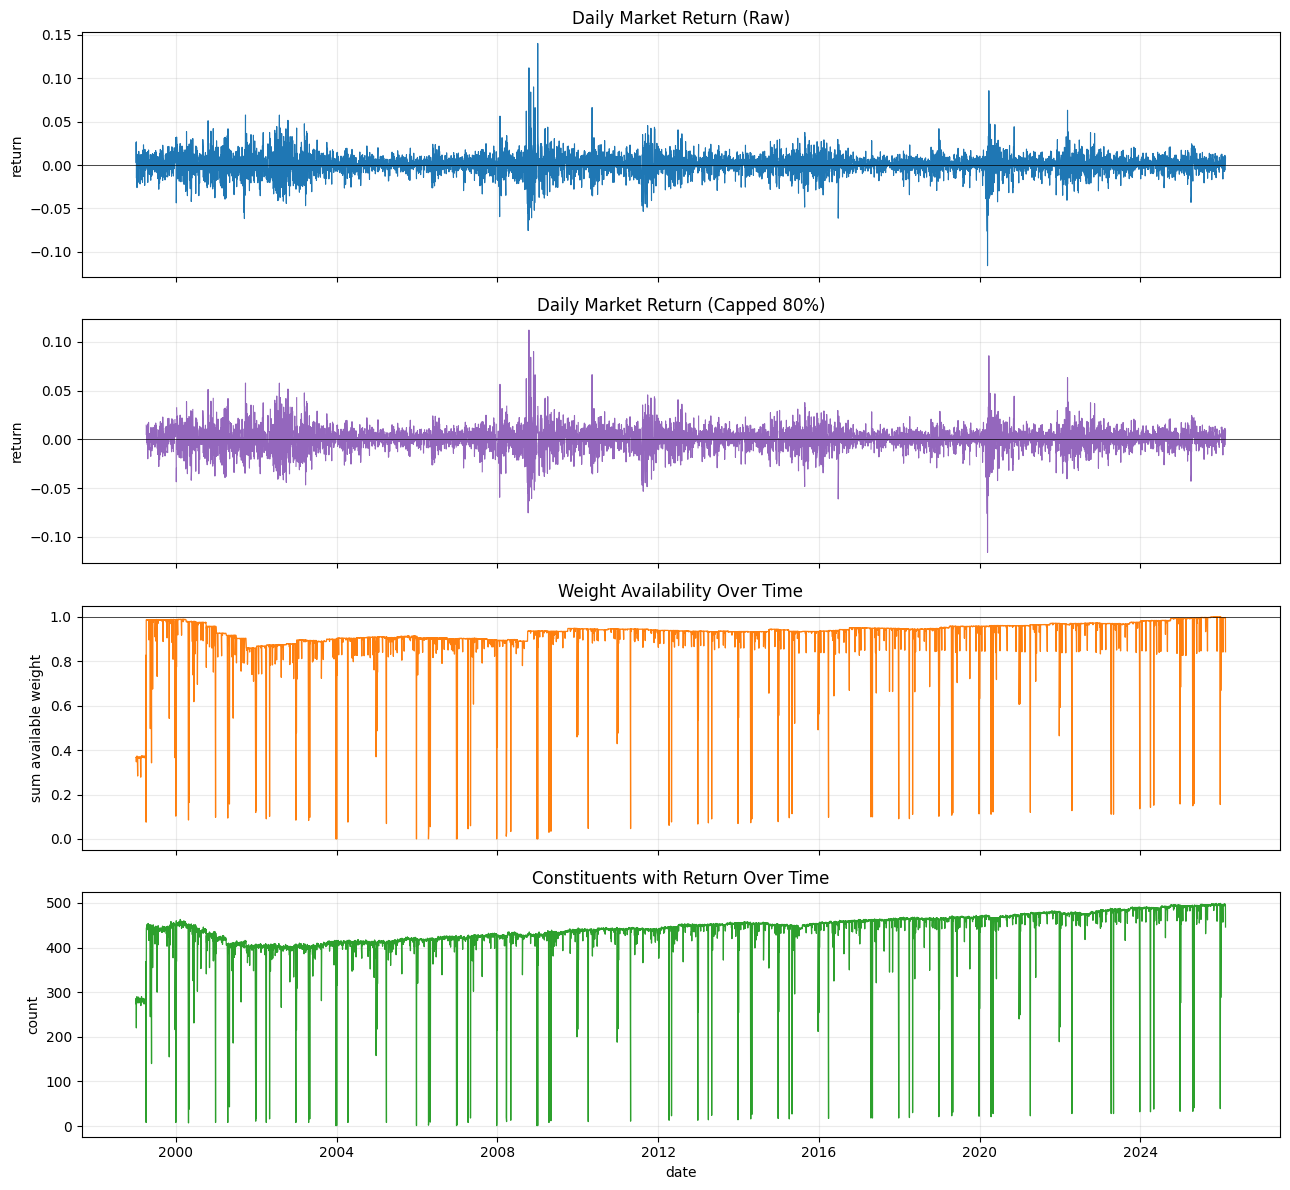

Worst 10 days by market return:


,date,quarter,market_return_ffmcap,weight_available,n_constituents_with_return
5484,2020-03-12,2020Q1,-0.115981,0.956325,470
5481,2020-03-09,2020Q1,-0.076307,0.956396,471
2530,2008-10-06,2008Q4,-0.075481,0.936163,430
2534,2008-10-10,2008Q4,-0.063956,0.935357,430
2537,2008-10-15,2008Q4,-0.062844,0.936188,430
699,2001-09-14,2001Q3,-0.061682,0.791854,402
4525,2016-06-24,2016Q2,-0.061237,0.901487,427
2553,2008-11-06,2008Q4,-0.060818,0.934862,427
2345,2008-01-21,2008Q1,-0.059480,0.865623,419
5486,2020-03-16,2020Q1,-0.058045,0.957313,472


Days with lowest weight availability:


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return
1807,2005-12-26,2005Q4,-0.015801,NaN,0.000033,1
2593,2009-01-01,2009Q1,0.140187,NaN,0.000058,1
1292,2004-01-01,2004Q1,0.000000,NaN,0.000077,1
1287,2003-12-25,2003Q4,-0.007239,NaN,0.000084,1
2588,2008-12-25,2008Q4,0.011084,NaN,0.000112,1
2067,2006-12-25,2006Q4,-0.013936,NaN,0.000146,1
2327,2007-12-25,2007Q4,-0.001200,NaN,0.000191,1
1886,2006-04-14,2006Q2,0.000000,NaN,0.000613,2
2072,2007-01-01,2007Q1,-0.000222,NaN,0.000800,3
2389,2008-03-21,2008Q1,-0.000147,NaN,0.012421,19


In [534]:
import matplotlib.pyplot as plt

diag = market_daily_out.copy()
diag["date"] = pd.to_datetime(diag["date"], errors="coerce")
diag = diag.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

stats = {
    "obs_days": int(len(diag)),
    "start": diag["date"].min(),
    "end": diag["date"].max(),
    "mean_daily_return": float(diag["market_return_ffmcap"].mean()),
    "vol_daily_return": float(diag["market_return_ffmcap"].std()),
    "mean_daily_return_capped80": float(diag["market_return_ffmcap_capped80"].mean()),
    "vol_daily_return_capped80": float(diag["market_return_ffmcap_capped80"].std()),
    "mean_weight_available": float(diag["weight_available"].mean()),
    "p5_weight_available": float(diag["weight_available"].quantile(0.05)),
    "mean_constituents_with_return": float(diag["n_constituents_with_return"].mean()),
}
print("Market index diagnostics:")
for k, v in stats.items():
    print(f"  {k}: {v}")

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

axes[0].plot(diag["date"], diag["market_return_ffmcap"], lw=0.8, color="tab:blue")
axes[0].axhline(0.0, color="black", lw=0.7, alpha=0.7)
axes[0].set_title("Daily Market Return (Raw)")
axes[0].set_ylabel("return")
axes[0].grid(alpha=0.25)

axes[1].plot(diag["date"], diag["market_return_ffmcap_capped80"], lw=0.8, color="tab:purple")
axes[1].axhline(0.0, color="black", lw=0.7, alpha=0.7)
axes[1].set_title("Daily Market Return (Capped 80%)")
axes[1].set_ylabel("return")
axes[1].grid(alpha=0.25)

axes[2].plot(diag["date"], diag["weight_available"], color="tab:orange", lw=0.9)
axes[2].axhline(1.0, color="black", lw=0.7, alpha=0.7)
axes[2].set_title("Weight Availability Over Time")
axes[2].set_ylabel("sum available weight")
axes[2].grid(alpha=0.25)

axes[3].plot(diag["date"], diag["n_constituents_with_return"], color="tab:green", lw=0.9)
axes[3].set_title("Constituents with Return Over Time")
axes[3].set_ylabel("count")
axes[3].set_xlabel("date")
axes[3].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Worst 10 days by market return:")
display(
    diag.nsmallest(10, "market_return_ffmcap")[
        ["date", "quarter", "market_return_ffmcap", "weight_available", "n_constituents_with_return"]
    ]
)

print("Days with lowest weight availability:")
display(
    diag.nsmallest(10, "weight_available")[
        ["date", "quarter", "market_return_ffmcap", "market_return_ffmcap_capped80", "weight_available", "n_constituents_with_return"]
    ]
)

## 2.7 Benchmark Pull and Comparison (STOXX 600, STOXX EURO 50)

Benchmark pull meta (TR-only):


,ric,series_name,field_used,is_total_return,start_date,end_date,n_obs
0,.STOXXR,stoxx600_ret,TR.PriceClose->pct_change,True,2004-10-05,2026-02-12,5474
1,.STOXX50ER,stoxx_euro50_ret,TR.PriceClose->pct_change,True,2003-11-03,2026-02-12,5489


Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_returns.parquet
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500_returns.parquet
Benchmark comparison stats:


,lhs,rhs,n,corr,beta,te
0,market_return_ffmcap,stoxx600_ret,5474,0.964620,0.974156,0.002977
1,market_return_ffmcap,stoxx_euro50_ret,5484,0.884657,0.699497,0.006760
2,market_return_ffmcap_capped80,stoxx600_ret,5419,0.965511,0.973737,0.002950
3,market_return_ffmcap_capped80,stoxx_euro50_ret,5424,0.885579,0.699126,0.006776


market_return_ffmcap_capped80: first_ret=0.003238, abs_q99=0.0401
stoxx600_ret: first_ret=0.000875, abs_q99=0.0377
stoxx_euro50_ret: first_ret=-0.413521, abs_q99=0.0468


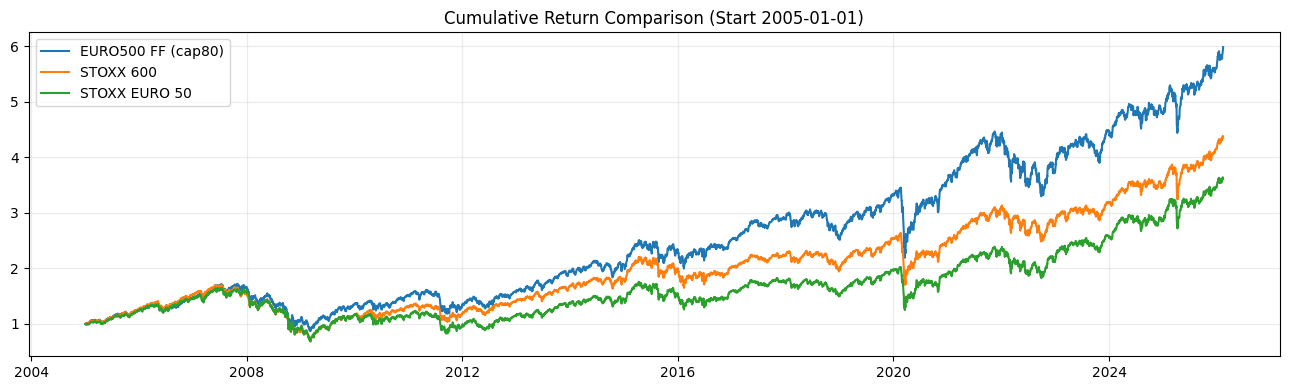

In [535]:
def pull_index_daily_return(ric: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    """
    Pull daily benchmark returns from LSEG using Total-Return-like fields only.
    """
    tr_fields = [
        "TR.TotalReturn",
        "TR.IndexTotalReturn",
        "TR.IndexGrossReturn",
        "TR.IndexNetReturn",
    ]
    price_fields = [
        "TR.PriceClose",
        "CLOSE",
    ]

    last_err = None
    tried = []

    def _coerce_num(s: pd.Series) -> pd.Series:
        # Handles values like "0.45%", "1,234.5", etc.
        t = s.astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False).str.strip()
        t = t.replace({"": np.nan, "None": np.nan, "nan": np.nan})
        return pd.to_numeric(t, errors="coerce")

    for field in tr_fields:
        tried.append(field)
        try:
            raw = ld.get_history(
                universe=[ric],
                fields=[field],
                start=start.strftime("%Y-%m-%d"),
                end=end.strftime("%Y-%m-%d"),
                interval="daily",
            )
            if raw is None or len(raw) == 0:
                continue

            x = raw.copy().reset_index()
            if x.empty:
                continue

            date_col = x.columns[0]
            value_candidates = [c for c in x.columns if c != date_col]
            if not value_candidates:
                continue

            # Choose the column that yields the most numeric observations.
            best_col = None
            best_non_na = -1
            for c in value_candidates:
                non_na = int(_coerce_num(x[c]).notna().sum())
                if non_na > best_non_na:
                    best_non_na = non_na
                    best_col = c
            if best_col is None or best_non_na <= 0:
                continue

            out = pd.DataFrame({
                "date": pd.to_datetime(x[date_col], errors="coerce"),
                "value": _coerce_num(x[best_col]),
            }).dropna(subset=["date", "value"]).sort_values("date")
            if out.empty:
                continue

            # TR-like series can come as percent points or decimals.
            max_abs = out["value"].abs().quantile(0.99)
            out["ret"] = out["value"] / 100.0 if max_abs > 1.5 else out["value"]
            out = out.dropna(subset=["ret"]).copy()
            if out.empty:
                continue

            out["ric"] = ric
            out["field_used"] = field
            out["is_total_return"] = True
            return out[["date", "ric", "field_used", "is_total_return", "ret"]]

        except Exception as e:
            last_err = e
            continue

    # Fallback for return-index RICs (e.g., .STOXXR/.STOXX50ER):
    # use index level (PriceClose/Close) and convert to daily returns.
    # This remains TR-consistent because the RIC itself is a return index.
    for field in price_fields:
        tried.append(field)
        try:
            raw = ld.get_history(
                universe=[ric],
                fields=[field],
                start=start.strftime("%Y-%m-%d"),
                end=end.strftime("%Y-%m-%d"),
                interval="daily",
            )
            if raw is None or len(raw) == 0:
                continue

            x = raw.copy().reset_index()
            if x.empty:
                continue

            date_col = x.columns[0]
            value_candidates = [c for c in x.columns if c != date_col]
            if not value_candidates:
                continue

            best_col = None
            best_non_na = -1
            for c in value_candidates:
                non_na = int(_coerce_num(x[c]).notna().sum())
                if non_na > best_non_na:
                    best_non_na = non_na
                    best_col = c
            if best_col is None or best_non_na <= 1:
                continue

            out = pd.DataFrame({
                "date": pd.to_datetime(x[date_col], errors="coerce"),
                "value": _coerce_num(x[best_col]),
            }).dropna(subset=["date", "value"]).sort_values("date")
            if len(out) <= 1:
                continue

            out["ret"] = out["value"].pct_change()
            out = out.dropna(subset=["ret"]).copy()
            if out.empty:
                continue

            out["ric"] = ric
            out["field_used"] = f"{field}->pct_change"
            out["is_total_return"] = True
            return out[["date", "ric", "field_used", "is_total_return", "ret"]]

        except Exception as e:
            last_err = e
            continue

    msg = f"No usable TR benchmark series for {ric}. Tried fields: {tried}"
    if last_err is not None:
        msg += f" | last error: {type(last_err).__name__}: {last_err}"
    raise ValueError(msg)


start_dt = pd.to_datetime(market_daily_out["date"]).min()
end_dt = pd.to_datetime(market_daily_out["date"]).max()

bench_list = [
    (".STOXXR", "stoxx600_ret"),
    (".STOXX50ER", "stoxx_euro50_ret"),
]

bench_frames = []
bench_meta = []
ld.open_session()
try:
    for ric, col_name in bench_list:
        b = pull_index_daily_return(ric=ric, start=start_dt, end=end_dt).rename(columns={"ret": col_name})
        if b.empty:
            raise ValueError(f"Benchmark pull returned empty frame for {ric}")
        bench_frames.append(b[["date", col_name]])
        bench_meta.append({
            "ric": ric,
            "series_name": col_name,
            "field_used": b["field_used"].iloc[0],
            "is_total_return": bool(b["is_total_return"].iloc[0]),
            "start_date": b["date"].min(),
            "end_date": b["date"].max(),
            "n_obs": int(len(b)),
        })
finally:
    ld.close_session()

if len(bench_frames) != len(bench_list):
    raise ValueError("Not all benchmark TR series were pulled successfully (.STOXXR / .STOXX50ER).")

bench_meta_df = pd.DataFrame(bench_meta)
print("Benchmark pull meta (TR-only):")
display(bench_meta_df)

bench = bench_frames[0]
for b in bench_frames[1:]:
    bench = bench.merge(b, on="date", how="outer")
bench = bench.sort_values("date").reset_index(drop=True)

cmp_df = market_daily_out.merge(
    bench,
    on="date",
    how="left",
)
save_parquet(cmp_df, "euro500_returns")
print("Saved:", DATA_DIR / "euro500_returns.parquet")

def _cmp_stats(x: pd.Series, y: pd.Series) -> dict:
    z = pd.concat([x, y], axis=1).dropna()
    if z.empty:
        return {"n": 0, "corr": np.nan, "beta": np.nan, "te": np.nan}
    xv = z.iloc[:, 0]
    yv = z.iloc[:, 1]
    cov = np.cov(xv, yv)[0, 1]
    var_y = np.var(yv)
    beta = cov / var_y if var_y > 0 else np.nan
    te = float((xv - yv).std())
    return {"n": int(len(z)), "corr": float(xv.corr(yv)), "beta": float(beta), "te": te}

rows = []
for lhs_name in ["market_return_ffmcap", "market_return_ffmcap_capped80"]:
    for rhs_name in ["stoxx600_ret", "stoxx_euro50_ret"]:
        if rhs_name in cmp_df.columns:
            st = _cmp_stats(cmp_df[lhs_name], cmp_df[rhs_name])
            rows.append({"lhs": lhs_name, "rhs": rhs_name, **st})
cmp_stats = pd.DataFrame(rows)

print("Benchmark comparison stats:")
display(cmp_stats)

def _normalized_cum_level(ret_series: pd.Series) -> pd.Series:
    x = pd.to_numeric(ret_series, errors="coerce")
    lvl = (1.0 + x.fillna(0.0)).cumprod()
    first_valid = lvl.dropna()
    if first_valid.empty:
        return lvl * np.nan
    return lvl / first_valid.iloc[0]

# quick sanity check on first observed returns
for c in ["market_return_ffmcap_capped80", "stoxx600_ret", "stoxx_euro50_ret"]:
    if c in cmp_df.columns:
        s = pd.to_numeric(cmp_df[c], errors="coerce").dropna()
        if len(s) > 0:
            print(f"{c}: first_ret={s.iloc[0]:.6f}, abs_q99={s.abs().quantile(0.99):.4f}")

PLOT1_START = pd.Timestamp("2005-01-01")
cmp_plot1 = cmp_df[cmp_df["date"] >= PLOT1_START].copy()

fig, ax = plt.subplots(1, 1, figsize=(13, 4))
ax.plot(cmp_plot1["date"], _normalized_cum_level(cmp_plot1["market_return_ffmcap_capped80"]), label="EURO500 FF (cap80)")
if "stoxx600_ret" in cmp_plot1.columns:
    ax.plot(cmp_plot1["date"], _normalized_cum_level(cmp_plot1["stoxx600_ret"]), label="STOXX 600")
if "stoxx_euro50_ret" in cmp_plot1.columns:
    ax.plot(cmp_plot1["date"], _normalized_cum_level(cmp_plot1["stoxx_euro50_ret"]), label="STOXX EURO 50")
ax.set_title("Cumulative Return Comparison (Start 2005-01-01)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 2.7B Relative Performance Views

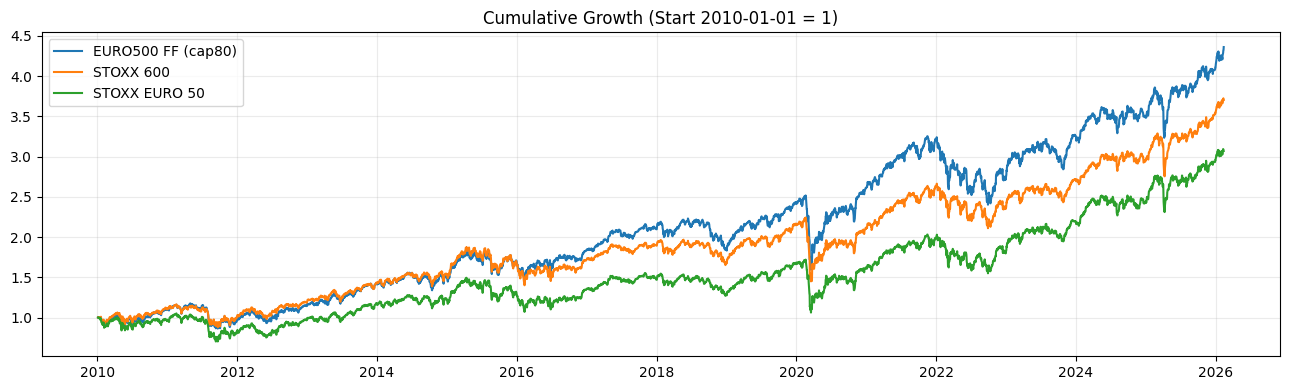

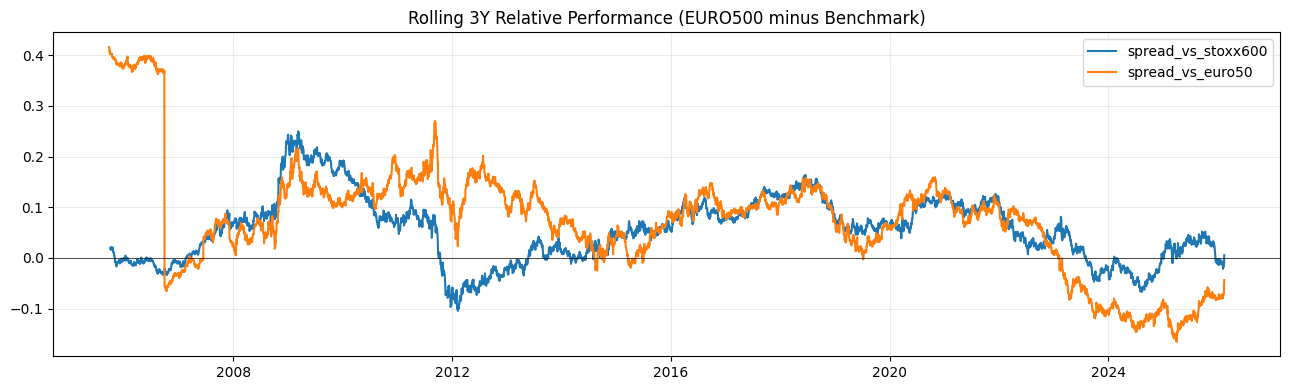

Annual return spread table:


,year,euro500_ann,stoxx_euro50_ann,spread_vs_euro50,stoxx600_ann,spread_vs_stoxx600
13,2012,0.186576,0.180566,0.006010,0.181801,0.004776
14,2013,0.248608,0.215056,0.033552,0.207883,0.040725
15,2014,0.049345,0.040083,0.009262,0.071995,-0.022650
16,2015,0.135912,0.064153,0.071759,0.096014,0.039898
17,2016,0.077233,0.037151,0.040082,0.017319,0.059914
18,2017,0.145584,0.091523,0.054062,0.105771,0.039813
19,2018,-0.112068,-0.120256,0.008188,-0.107670,-0.004398
20,2019,0.294083,0.282016,0.012067,0.268186,0.025897
21,2020,0.081472,-0.032051,0.113522,-0.019923,0.101394
22,2021,0.232318,0.233435,-0.001118,0.249093,-0.016776


In [536]:
cmp_plot = cmp_df.copy()
cmp_plot["date"] = pd.to_datetime(cmp_plot["date"], errors="coerce")
cmp_plot = cmp_plot.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

START_NORM = pd.Timestamp("2010-01-01")
cmp_norm = cmp_plot[cmp_plot["date"] >= START_NORM].copy()

series_cols = [
    "market_return_ffmcap_capped80",
    "stoxx600_ret",
    "stoxx_euro50_ret",
]
series_cols = [c for c in series_cols if c in cmp_norm.columns]

for c in series_cols:
    cmp_norm[f"lvl_{c}"] = _normalized_cum_level(cmp_norm[c])

fig, ax = plt.subplots(1, 1, figsize=(13, 4))
if "lvl_market_return_ffmcap_capped80" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_market_return_ffmcap_capped80"], label="EURO500 FF (cap80)")
if "lvl_stoxx600_ret" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_stoxx600_ret"], label="STOXX 600")
if "lvl_stoxx_euro50_ret" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_stoxx_euro50_ret"], label="STOXX EURO 50")
ax.set_title("Cumulative Growth (Start 2010-01-01 = 1)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# 3Y (756 trading days) rolling relative performance vs benchmarks
rolling_win = 756
rel = cmp_plot[["date", "market_return_ffmcap_capped80"]].copy()
if "stoxx600_ret" in cmp_plot.columns:
    rel["spread_vs_stoxx600"] = cmp_plot["market_return_ffmcap_capped80"] - cmp_plot["stoxx600_ret"]
if "stoxx_euro50_ret" in cmp_plot.columns:
    rel["spread_vs_euro50"] = cmp_plot["market_return_ffmcap_capped80"] - cmp_plot["stoxx_euro50_ret"]

roll = rel[["date"]].copy()
for c in [x for x in rel.columns if x.startswith("spread_")]:
    # Robust rolling sum: allow partial missing observations but require enough valid days.
    valid_cnt = rel[c].notna().rolling(rolling_win, min_periods=1).sum()
    rsum = rel[c].fillna(0.0).rolling(rolling_win, min_periods=252).sum()
    rsum[valid_cnt < 252] = np.nan
    roll[f"roll3y_{c}"] = rsum

fig, ax = plt.subplots(1, 1, figsize=(13, 4))
for c in [x for x in roll.columns if x.startswith("roll3y_")]:
    ax.plot(roll["date"], roll[c], label=c.replace("roll3y_", ""))
ax.axhline(0.0, color="black", lw=0.7, alpha=0.7)
ax.set_title("Rolling 3Y Relative Performance (EURO500 minus Benchmark)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Yearly return spread table
annual = cmp_plot.copy()
annual["year"] = annual["date"].dt.year
ann_rows = []
for y, g in annual.groupby("year"):
    row = {"year": int(y)}
    if g["market_return_ffmcap_capped80"].notna().any():
        row["euro500_ann"] = float((1 + g["market_return_ffmcap_capped80"].fillna(0)).prod() - 1)
    if "stoxx600_ret" in g.columns and g["stoxx600_ret"].notna().any():
        row["stoxx600_ann"] = float((1 + g["stoxx600_ret"].fillna(0)).prod() - 1)
        row["spread_vs_stoxx600"] = row.get("euro500_ann", np.nan) - row["stoxx600_ann"]
    if "stoxx_euro50_ret" in g.columns and g["stoxx_euro50_ret"].notna().any():
        row["stoxx_euro50_ann"] = float((1 + g["stoxx_euro50_ret"].fillna(0)).prod() - 1)
        row["spread_vs_euro50"] = row.get("euro500_ann", np.nan) - row["stoxx_euro50_ann"]
    ann_rows.append(row)

annual_spread = pd.DataFrame(ann_rows).sort_values("year").reset_index(drop=True)
print("Annual return spread table:")
display(annual_spread.tail(15))

## 2.8 Hard Validation Tests

In [537]:
def _te(a: pd.Series, b: pd.Series) -> float:
    z = pd.concat([a, b], axis=1).dropna()
    if z.empty:
        return np.nan
    return float((z.iloc[:, 0] - z.iloc[:, 1]).std())


def _beta(a: pd.Series, b: pd.Series) -> float:
    z = pd.concat([a, b], axis=1).dropna()
    if len(z) < 3:
        return np.nan
    x = z.iloc[:, 0]
    y = z.iloc[:, 1]
    var_y = np.var(y)
    if var_y <= 0:
        return np.nan
    return float(np.cov(x, y)[0, 1] / var_y)


# Test 1: scale sanity (daily return magnitude should be plausible)
scale_rows = []
for c in ["market_return_ffmcap", "market_return_ffmcap_capped80", "stoxx600_ret", "stoxx_euro50_ret"]:
    if c in cmp_df.columns:
        x = pd.to_numeric(cmp_df[c], errors="coerce").dropna()
        if len(x) == 0:
            continue
        q95 = float(x.abs().quantile(0.95))
        q99 = float(x.abs().quantile(0.99))
        mx = float(x.abs().max())
        scale_rows.append({
            "series": c,
            "n": int(len(x)),
            "abs_q95": q95,
            "abs_q99": q99,
            "abs_max": mx,
            "scale_flag": "WARN" if q99 > 0.20 else "PASS",
        })
scale_df = pd.DataFrame(scale_rows)

# Test 2: cap impact
raw = pd.to_numeric(market_daily_out["market_return_ffmcap"], errors="coerce")
cap = pd.to_numeric(market_daily_out["market_return_ffmcap_capped80"], errors="coerce")
wa = pd.to_numeric(market_daily_out["weight_available"], errors="coerce")
dropped = int(cap.isna().sum())
cap_test = pd.DataFrame([{
    "n_days": int(len(market_daily_out)),
    "dropped_days_cap80": dropped,
    "drop_share": float(dropped / len(market_daily_out)) if len(market_daily_out) else np.nan,
    "raw_vol": float(raw.std()),
    "cap80_vol": float(cap.std()),
    "raw_abs_q99": float(raw.abs().quantile(0.99)),
    "cap80_abs_q99": float(cap.abs().quantile(0.99)),
}])

# Test 3: outlier/availability linkage
z = (raw - raw.mean()) / raw.std()
outlier = z.abs() > 3
link_test = pd.DataFrame([{
    "corr_absret_vs_missing_weight": float(raw.abs().corr(1 - wa)),
    "corr_outlier_vs_missing_weight": float(outlier.astype(float).corr(1 - wa)),
}])

# Test 4: benchmark alignment raw vs cap80
bench_rows = []
for rhs in ["stoxx600_ret", "stoxx_euro50_ret"]:
    if rhs in cmp_df.columns:
        for lhs in ["market_return_ffmcap", "market_return_ffmcap_capped80"]:
            zz = pd.concat([cmp_df[lhs], cmp_df[rhs]], axis=1).dropna()
            corr = float(zz.iloc[:, 0].corr(zz.iloc[:, 1])) if len(zz) else np.nan
            bench_rows.append({
                "lhs": lhs,
                "rhs": rhs,
                "n": int(len(zz)),
                "corr": corr,
                "beta": _beta(cmp_df[lhs], cmp_df[rhs]),
                "tracking_error": _te(cmp_df[lhs], cmp_df[rhs]),
                "alignment_flag": "PASS" if (pd.notna(corr) and corr >= 0.70) else "WARN",
            })
bench_test = pd.DataFrame(bench_rows)

# Test 5: fragile days (very low availability and very few names)
fragile = market_daily_out[
    (market_daily_out["weight_available"] < 0.80)
    | (market_daily_out["n_constituents_with_return"] < 50)
].copy()
fragile = fragile.sort_values(["weight_available", "n_constituents_with_return"]).head(20)

print("Hard test 1: scale sanity")
display(scale_df)
print("Hard test 2: cap impact (80%)")
display(cap_test)
print("Hard test 3: outlier vs availability linkage")
display(link_test)
print("Hard test 4: benchmark alignment")
display(bench_test)
print("Hard test 5: fragile days (lowest availability / few constituents)")
display(fragile[["date", "quarter", "market_return_ffmcap", "market_return_ffmcap_capped80", "weight_available", "n_constituents_with_return"]])

Hard test 1: scale sanity


,series,n,abs_q95,abs_q99,abs_max,scale_flag
0,market_return_ffmcap,7015,0.024213,0.040496,0.140187,PASS
1,market_return_ffmcap_capped80,6784,0.024157,0.040085,0.115981,PASS
2,stoxx600_ret,5474,0.022229,0.037738,0.114640,PASS
3,stoxx_euro50_ret,5484,0.026703,0.046791,0.413521,PASS


Hard test 2: cap impact (80%)


,n_days,dropped_days_cap80,drop_share,raw_vol,cap80_vol,raw_abs_q99,cap80_abs_q99
0,7015,231,0.032929,0.012059,0.011943,0.040496,0.040085


Hard test 3: outlier vs availability linkage


,corr_absret_vs_missing_weight,corr_outlier_vs_missing_weight
0,0.035991,0.020867


Hard test 4: benchmark alignment


,lhs,rhs,n,corr,beta,tracking_error,alignment_flag
0,market_return_ffmcap,stoxx600_ret,5474,0.964620,0.974156,0.002977,PASS
1,market_return_ffmcap_capped80,stoxx600_ret,5419,0.965511,0.973737,0.002950,PASS
2,market_return_ffmcap,stoxx_euro50_ret,5484,0.884657,0.699497,0.006760,PASS
3,market_return_ffmcap_capped80,stoxx_euro50_ret,5424,0.885579,0.699126,0.006776,PASS


Hard test 5: fragile days (lowest availability / few constituents)


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return
1807,2005-12-26,2005Q4,-0.015801,NaN,0.000033,1
2593,2009-01-01,2009Q1,0.140187,NaN,0.000058,1
1292,2004-01-01,2004Q1,0.000000,NaN,0.000077,1
1287,2003-12-25,2003Q4,-0.007239,NaN,0.000084,1
2588,2008-12-25,2008Q4,0.011084,NaN,0.000112,1
2067,2006-12-25,2006Q4,-0.013936,NaN,0.000146,1
2327,2007-12-25,2007Q4,-0.001200,NaN,0.000191,1
1886,2006-04-14,2006Q2,0.000000,NaN,0.000613,2
2072,2007-01-01,2007Q1,-0.000222,NaN,0.000800,3
2389,2008-03-21,2008Q1,-0.000147,NaN,0.012421,19


In [538]:
cov_by_q = (
    panel_all
    .groupby("date")["mcap_eur"]
    .apply(lambda s: s.notna().mean())
    .rename("mcap_coverage")
    .reset_index()
)

cov_by_q["n_universe"] = panel_all.groupby("date")["RIC"].nunique().values
cov_by_q["n_top500"] = euro500.groupby("date")["RIC"].nunique().reindex(cov_by_q["date"]).fillna(0).astype(int).values

print("Median mcap coverage:", f"{cov_by_q['mcap_coverage'].median():.1%}")
print("Worst 10 quarters by coverage:")
cov_by_q.sort_values("mcap_coverage").head(10)




Median mcap coverage: 100.0%
Worst 10 quarters by coverage:


,date,mcap_coverage,n_universe,n_top500
0,1998-12-31,1.0,529,500
78,2018-06-29,1.0,1500,500
77,2018-03-30,1.0,1500,500
76,2017-12-29,1.0,1500,500
75,2017-09-29,1.0,1500,500
74,2017-06-30,1.0,1500,500
73,2017-03-31,1.0,1500,500
72,2016-12-30,1.0,1500,500
71,2016-09-30,1.0,1500,500
70,2016-06-30,1.0,1500,500


In [539]:
euro500["RIC"].nunique()

1532

In [540]:
def assert_euro500_hq_countries_ok(euro500: pd.DataFrame) -> None:
    """
    Prints 'OK ✅' if, for every quarter, all HQ countries present in euro500
    are euro-eligible for the subsequent return period (per euro_hq_codes_for_quarter).
    Otherwise prints a short FAIL message.
    """
    for dt, g in euro500.groupby("date"):
        formation_date = pd.Timestamp(dt).normalize()
        allowed = set(euro_hq_codes_for_quarter(formation_date))

        present = set(
            g["hq_code"]
            .dropna()
            .astype(str)
            .str.strip()
            .str.upper()
            .unique()
        )

        viol = sorted(present - allowed)

        if len(viol) > 0:
            print("FAIL ❌")
            print("First problematic quarter (formation):", formation_date.date())
            print("Countries present but not euro-eligible:", viol)
            return

    print("OK ✅ All HQ countries in euro500 are correctly euro-eligible in every quarter.")

assert_euro500_hq_countries_ok(euro500)

OK ✅ All HQ countries in euro500 are correctly euro-eligible in every quarter.


## Analysis

In [541]:
country_share = (
    euro500
    .groupby(["date", "hq_code"])["RIC"]
    .nunique()
    .groupby("hq_code")
    .mean()
    .sort_values(ascending=False)
)

country_share_pct = 100 * country_share / country_share.sum()

country_share_pct.head(15)

hq_code
FR    23.463501
DE    20.623680
IT     9.397029
ES     8.463140
NL     6.757067
BE     6.335545
FI     5.926742
IE     4.542261
AT     4.106204
GR     3.228804
LU     2.369243
PT     2.338356
HR     0.517322
SI     0.421231
SK     0.343395
Name: RIC, dtype: float64

In [542]:
sector_share = (
    euro500
    .groupby(["date", "trbc_sector"])["RIC"]
    .nunique()
    .groupby("trbc_sector")
    .mean()
    .sort_values(ascending=False)
)

sector_share_pct = 100 * sector_share / sector_share.sum()
sector_share_pct

trbc_sector
Industrials                                   21.018650
Consumer Cyclicals                            18.172259
Technology                                    13.254257
Basic Materials                               11.483333
Healthcare                                     9.002195
Consumer Non-Cyclicals                         8.609272
Real Estate                                    7.325352
Utilities                                      5.877253
Energy                                         4.809165
Academic & Educational Services                0.249036
Institutions, Associations & Organizations     0.199229
Name: RIC, dtype: float64

### Analysis: STOXX600 EuroHQ vs EURO500 (Quarterly Deviations)

In [ ]:
STOXX_EUROHQ_PATH = DATA_DIR / "stoxx600_membership_matrix_1999_2025_eurohq.parquet"
if not STOXX_EUROHQ_PATH.exists():
    raise FileNotFoundError(f"Missing file: {STOXX_EUROHQ_PATH}")

stx = pd.read_parquet(STOXX_EUROHQ_PATH).copy()

year_cols = [c for c in stx.columns if str(c).isdigit()]
if not year_cols:
    raise ValueError("No year columns found in stoxx600 membership matrix.")

def normalize_ric(x: pd.Series) -> pd.Series:
    s = x.astype(str).str.strip().str.upper()
    # Historical RIC variants in matrix like 'ABC.DE^L25' -> 'ABC.DE'
    s = s.str.replace(r"\^.*$", "", regex=True)
    s = s.replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA})
    return s

stx["RIC_norm"] = normalize_ric(stx["ConstituentRIC"])

stx_long = (
    stx.melt(
        id_vars=["RIC_norm", "ConstituentRIC", "CompanyName", "CountryHQ"],
        value_vars=year_cols,
        var_name="year",
        value_name="in_index",
    )
    .assign(
        year=lambda d: pd.to_numeric(d["year"], errors="coerce").astype("Int64"),
        in_index=lambda d: pd.to_numeric(d["in_index"], errors="coerce").fillna(0).astype(int),
    )
)
stx_long = stx_long[(stx_long["in_index"] == 1) & stx_long["year"].notna() & stx_long["RIC_norm"].notna()].copy()

stx_members_by_year = (
    stx_long.groupby("year")["RIC_norm"]
    .apply(lambda x: set(x.dropna().astype(str)))
    .to_dict()
)

euro_cmp = euro500.copy()
euro_cmp["RIC_norm"] = normalize_ric(euro_cmp["RIC"])
euro_cmp["quarter"] = euro_cmp["quarter"].astype(str)

euro_members_by_quarter = (
    euro_cmp.groupby("quarter")["RIC_norm"]
    .apply(lambda x: set(x.dropna().astype(str)))
    .to_dict()
)

all_quarters = sorted(euro_members_by_quarter.keys(), key=lambda q: pd.Period(q, freq="Q"))

rows = []
missing_rows = []
stx_info = (
    stx[["RIC_norm", "ConstituentRIC", "CompanyName", "CountryHQ"]]
    .drop_duplicates(subset=["RIC_norm"], keep="first")
    .set_index("RIC_norm")
)

for q in all_quarters:
    y = int(q[:4])
    euro_set = euro_members_by_quarter.get(q, set())
    stx_set = stx_members_by_year.get(y, set())

    inter = euro_set & stx_set
    stx_not_in_euro = stx_set - euro_set
    euro_not_in_stx = euro_set - stx_set

    rows.append({
        "quarter": q,
        "year": y,
        "n_euro500": len(euro_set),
        "n_stoxx600_eurohq": len(stx_set),
        "n_intersection": len(inter),
        "n_stoxx_not_in_euro500": len(stx_not_in_euro),
        "n_euro500_not_in_stoxx": len(euro_not_in_stx),
        "share_stoxx_covered_by_euro500": (len(inter) / len(stx_set)) if len(stx_set) else np.nan,
    })

    for ric in sorted(stx_not_in_euro):
        info = stx_info.loc[ric] if ric in stx_info.index else None
        missing_rows.append({
            "quarter": q,
            "year": y,
            "RIC_norm": ric,
            "ConstituentRIC": info["ConstituentRIC"] if info is not None else pd.NA,
            "CompanyName": info["CompanyName"] if info is not None else pd.NA,
            "CountryHQ": info["CountryHQ"] if info is not None else pd.NA,
        })

stoxx_vs_euro500_q = pd.DataFrame(rows).sort_values("quarter").reset_index(drop=True)
stoxx_not_in_euro500 = pd.DataFrame(missing_rows).sort_values(["quarter", "RIC_norm"]).reset_index(drop=True)

print("Quarterly STOXX600 EuroHQ vs EURO500 summary:")
display(stoxx_vs_euro500_q.head(12))
display(stoxx_vs_euro500_q.tail(12))

print("Worst quarters by 'STOXX in, EURO500 out':")
display(
    stoxx_vs_euro500_q.sort_values("n_stoxx_not_in_euro500", ascending=False).head(10)
)

print("Examples: STOXX members missing in EURO500 (first 50 rows)")
display(stoxx_not_in_euro500.head(50))

In [543]:
# Prüfe leere Strings
empty_string_count = (euro500["ISIN"] == "").sum()
print("Empty string ISINs:", empty_string_count)

# Prüfe Whitespaces
whitespace_count = (euro500["ISIN"].astype(str).str.strip() == "").sum()
print("Whitespace-only ISINs:", whitespace_count)

Empty string ISINs: 0
Whitespace-only ISINs: 0


## Kopie für Dashboard erstellen

In [544]:
# --- gewünschte Spalten auswählen ---
export_df = euro500[[
    "date",
    "name",
    "hq_country",
    "trbc_sector",
    "mcap_eur",
    "ISIN",
    "rank_mcap",
    "MasterID"
]].copy()

# Umbenennen
export_df = export_df.rename(columns={
    "trbc_sector": "sector",
    "ISIN": "isin"
})

# --- mcap: letzte 6 Ziffern auf 0 setzen ---
# Beispiel: 1234567890 -> 1234000000
export_df["mcap_eur"] = (
    (export_df["mcap_eur"] // 1_000_000) * 1_000_000
).astype("Int64")

# --- Speicherpfad auf deinem Mac ---
output_path = Path(
    "/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/EURO500 Dashboard/euro500_dashboard_table.parquet"
)

# Ordner sicherstellen
output_path.parent.mkdir(parents=True, exist_ok=True)

# Speichern
export_df.to_parquet(output_path, index=False)

print("Saved to:", output_path)

Saved to: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/EURO500 Dashboard/euro500_dashboard_table.parquet
